In [1]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import matplotlib.pyplot as plt
import numpy as np

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()

print("Ready!")
print(f"Vocabulary size: {model.config.vocab_size}")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 5387.30it/s]


Ready!
Vocabulary size: 50257


In [2]:
text = "The cat sat on the"

inputs = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

# Logits 
logits = outputs.logits[0, -1, :]  # shape: [50257]

print(f"Input text: {text}")
print(f"Logits shape: {logits.shape}")
print(f"Logits min:  {logits.min():.2f}")
print(f"Logits max:  {logits.max():.2f}")
print(f"Logits mean: {logits.mean():.2f}")

Input text: The cat sat on the
Logits shape: torch.Size([50257])
Logits min:  -110.70
Logits max:  -80.65
Logits mean: -95.40


In [3]:
# Softmax se probabilities
probs = torch.softmax(logits, dim=0)

print(f"Probabilities sum: {probs.sum():.4f}")  # 1.0 hona chahiye
print(f"Max probability:   {probs.max():.4f}")
print(f"Min probability:   {probs.min():.6f}")

# Top 10 most likely next words
top10_probs, top10_ids = torch.topk(probs, 10)
top10_words = [tokenizer.decode([idx]) for idx in top10_ids]

print(f"\nTop 10 next words after '{text}':")
print("-"*35)
for word, prob in zip(top10_words, top10_probs):
    bar = "█" * int(prob * 200)
    print(f"  {word:12}: {prob:.4f} {bar}")

Probabilities sum: 1.0000
Max probability:   0.0764
Min probability:   0.000000

Top 10 next words after 'The cat sat on the':
-----------------------------------
   floor      : 0.0764 ███████████████
   bed        : 0.0653 █████████████
   couch      : 0.0541 ██████████
   ground     : 0.0521 ██████████
   edge       : 0.0478 █████████
   bench      : 0.0316 ██████
   table      : 0.0315 ██████
   sofa       : 0.0288 █████
   other      : 0.0199 ███
   back       : 0.0190 ███


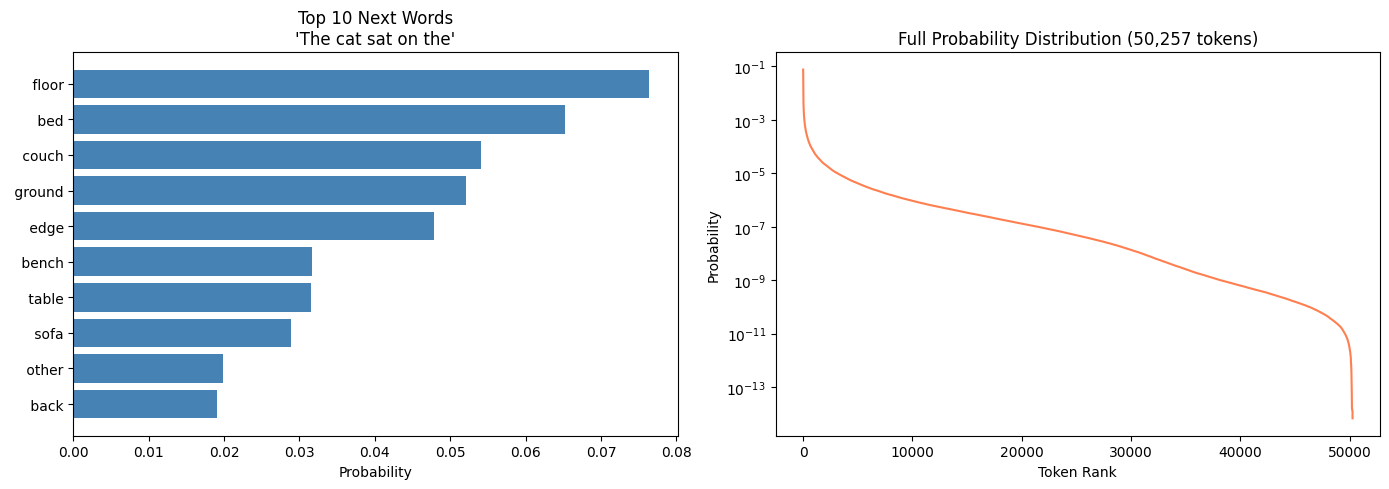

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 bar chart
axes[0].barh(top10_words[::-1], 
             top10_probs.numpy()[::-1],
             color="steelblue")
axes[0].set_xlabel("Probability")
axes[0].set_title(f"Top 10 Next Words\n'{text}'")

# Full distribution
axes[1].plot(sorted(probs.numpy(), reverse=True), 
             color="coral")
axes[1].set_xlabel("Token Rank")
axes[1].set_ylabel("Probability")
axes[1].set_title("Full Probability Distribution (50,257 tokens)")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

* At each step, an LLM like GPT-2 chooses from **50,257 possible tokens**.

* The model first produces **raw logits**, which are often negative and **cannot be used directly**.

* These logits are passed through **Softmax** (Softmax Function), which converts them into **probabilities that sum to 1.0**.

* Even the top predicted word may have only **~7.64% probability**, showing that the model is **inherently uncertain**.

* The probability distribution has a **long tail**: a few tokens have relatively high probability, while the majority have **near-zero probability**.
